# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

19

In [3]:
reports_paths.sort_values(ascending=False).head()

4     data/cash_app_report_1783629391249.csv
10    data/cash_app_report_1783439681167.csv
11    data/cash_app_report_1783357451480.csv
18    data/cash_app_report_1783012238287.csv
0     data/cash_app_report_1782999354380.csv
dtype: object

In [4]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1783629391249.csv')

In [5]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-09 15:56:07 EDT,#D-55D1758ZR,P2P,USD,$5.00,$0.00,$5.00,NaN,NaN,NaN,COMPLETE,Thank you for taking our survey!,Cash App,Cash Balance
1,2026-07-09 12:52:07 EDT,NaN,Stock Dividends,USD,$0.02,$0.00,$0.02,TSM,NaN,NaN,COMPLETE,$0.02 Dividend from Taiwan Semiconductor Manuf...,NaN,Cash Balance
2,2026-07-09 12:35:34 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,TGT,$134.06,0.074590,COMPLETE,$10 Purchase of Target,NaN,Cash Balance
3,2026-07-09 12:35:19 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,WMT,$111.73,0.089490,COMPLETE,$10 Purchase of Walmart,NaN,Cash Balance
4,2026-07-08 13:05:18 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,XYZ,$76.07,0.131450,COMPLETE,$10 Purchase of Block,NaN,Cash Balance
5,2026-07-08 00:00:00 EDT,NaN,Stock Dividends,USD,$0.07,$0.00,$0.07,MRK,NaN,NaN,COMPLETE,$0.07 Dividend from Merck,NaN,Cash Balance
6,2026-07-07 09:31:54 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,ORCL,$144.47,0.069210,COMPLETE,$10 Purchase of Oracle,NaN,Cash Balance
7,2026-07-07 09:30:16 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,AMZN,$247.12,0.040460,COMPLETE,$10 Purchase of Amazon,NaN,Cash Balance
8,2026-07-07 09:30:02 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,WMT,$112.96,0.088520,COMPLETE,$10 Purchase of Walmart,NaN,Cash Balance
9,2026-07-06 12:44:23 EDT,NaN,Bitcoin Sell,USD,$10.00,-$0.20,$9.80,BTC,"$63,170.74",0.000158,COMPLETE,sale of BTC 0.00015830,NaN,Cash Balance


In [6]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
123,2026-06-22 09:30:20 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DKS,$237.13,0.04217,COMPLETE,$10 Sale of Dick's Sporting Goods,NaN,Cash Balance
184,2026-06-16 11:45:45 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,LITE,$868.45,0.01151,COMPLETE,$10 Sale of Lumentum,NaN,Cash Balance
110,2026-06-22 13:16:52 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$33.58,0.29775,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance
68,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
29,2026-07-02 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,LITE,$778.00,0.01285,COMPLETE,$10 Sale of Lumentum,NaN,Cash Balance
157,2026-06-18 13:09:36 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,VNQ,$96.10,0.10405,COMPLETE,$10 Sale of Vanguard Real Estate ETF,NaN,Cash Balance
308,2026-06-04 09:30:07 EDT,NaN,NaN,USD,$10.21,$0.00,$10.21,OWL,$9.79,1.04329,COMPLETE,$10.21 Sale of Blue Owl Capital,NaN,Cash Balance
24,2026-07-02 13:07:21 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,V,$358.68,0.05575,COMPLETE,$20 Sale of Visa,NaN,Cash Balance
35,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
114,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance


In [7]:
data_raw['Asset Amount'].fillna(None).astype(float)

0          NaN
1          NaN
2      0.07459
3      0.08949
4      0.13145
        ...   
681        NaN
682        NaN
683        NaN
684        NaN
685        NaN
Name: Asset Amount, Length: 686, dtype: float64

In [8]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
653,2026-05-27 13:30:04+00:00,-5.0,-5.0,305.00,0.016390,0.0,JPM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of JPMorgan Chase,NaN
593,2026-05-30 16:44:46+00:00,-5.0,-4.9,74401.94,0.000066,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00006586,NaN
496,2026-06-03 13:30:01+00:00,-10.0,-10.0,44.34,0.225520,0.0,PYPL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of PayPal,NaN
447,2026-06-03 13:30:16+00:00,-10.0,-10.0,104.82,0.095400,0.0,VONV,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Russell 1000 Value ETF,NaN
378,2026-06-03 16:56:00+00:00,-10.0,-10.0,99.71,0.100290,0.0,DIS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Disney,NaN
253,2026-06-15 13:30:03+00:00,-5.0,-5.0,490.50,0.010190,0.0,MA,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Mastercard,NaN
198,2026-06-16 13:31:22+00:00,-10.0,-10.0,413.53,0.024180,0.0,DELL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Dell Technologies,NaN
173,2026-06-18 14:06:52+00:00,-5.0,-5.0,50.45,0.099110,0.0,VTEB,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Vanguard Tax-Exempt Bond ETF,NaN
113,2026-06-22 13:33:17+00:00,10.0,10.0,82.92,0.120590,0.0,WFC,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Wells Fargo,NaN
112,2026-06-22 13:33:29+00:00,-10.0,-10.0,133.40,0.074960,0.0,TGT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Target,NaN


In [9]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
0,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
679,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
680,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
681,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
683,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
684,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
685,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


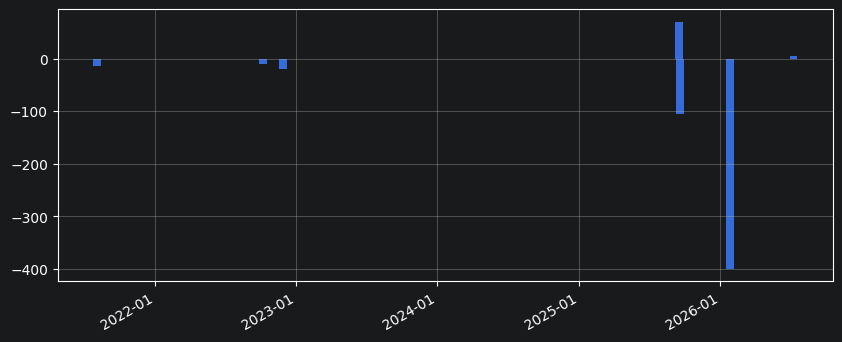

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [11]:
data.describe()

,net_amount,amount,asset_price,asset_amount,fee
count,686.000000,686.000000,555.000000,686.000000,683.000000
mean,-0.008440,0.001531,4058.629459,0.140284,-0.010015
std,37.437622,37.435768,15993.628431,0.331200,0.054857
min,-400.000000,-400.000000,2.220000,0.000000,-0.500000
25%,-10.000000,-10.000000,57.235000,0.007935,0.000000
50%,-10.000000,-10.000000,133.220000,0.044975,0.000000
75%,-1.000000,-1.000000,302.100000,0.127053,0.000000
max,200.000000,200.000000,80346.140000,4.509170,0.000000


In [12]:
data.nunique().sort_values(ascending=False)

asset_price     546
asset_amount    542
date            540
notes           395
asset_type      167
amount           60
net_amount       59
trans_type       10
trans_id          8
fee               6
name_trans        6
account           5
status            2
currency          1
dtype: int64

In [13]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      31
XYZ      14
ORCL     12
JPM      12
AMZN     11
META     11
WFC      11
V        10
MCD      10
PZZA     10
DELL      8
MSFT      8
GOOG      8
VONV      8
GOOGL     8
UBER      8
NFLX      7
VMBS      7
FISV      7
HOOD      7
DOW       7
WMT       6
AAPL      6
INTU      6
PYPL      6
Name: count, dtype: int64

Text(0, 0.5, 'Count')

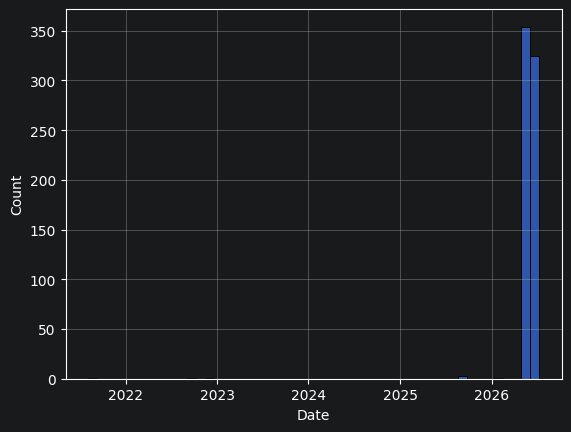

In [14]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [15]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-04-23,2026-05-27,2026-05-29,2026-06-02,2026-06-03,2026-06-18,2026-07-01,2026-07-02,2026-07-07


In [16]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,31,-156.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
XYZ,14,-181.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
ORCL,12,-105.00,"(-10.0, -5.0)",2
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
AMZN,11,-171.00,"(-50.0, -25.0, -10.0, -1.0)",4
META,11,-80.95,"(-10.0, -5.0, -1.0, 0.05)",4
WFC,11,-51.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4
MCD,10,-99.80,"(-25.0, -10.0, -5.0, 0.2)",4


In [17]:
data['currency'].value_counts()

currency
USD    686
Name: count, dtype: int64

In [18]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    478
Deposits                      65
Stock Sell                    46
Stock Dividends               43
Bitcoin Buy                   24
Savings Internal Transfer     12
P2P                            7
Bitcoin Sell                   7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [19]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,7,478,43,46,598
BTC,24,7,0,0,0,31
XYZ,0,0,13,0,1,14
ORCL,0,0,12,0,0,12
JPM,0,0,10,0,2,12
AMZN,0,0,11,0,0,11
META,0,0,10,1,0,11
WFC,0,0,9,0,2,11
MCD,0,0,9,1,0,10


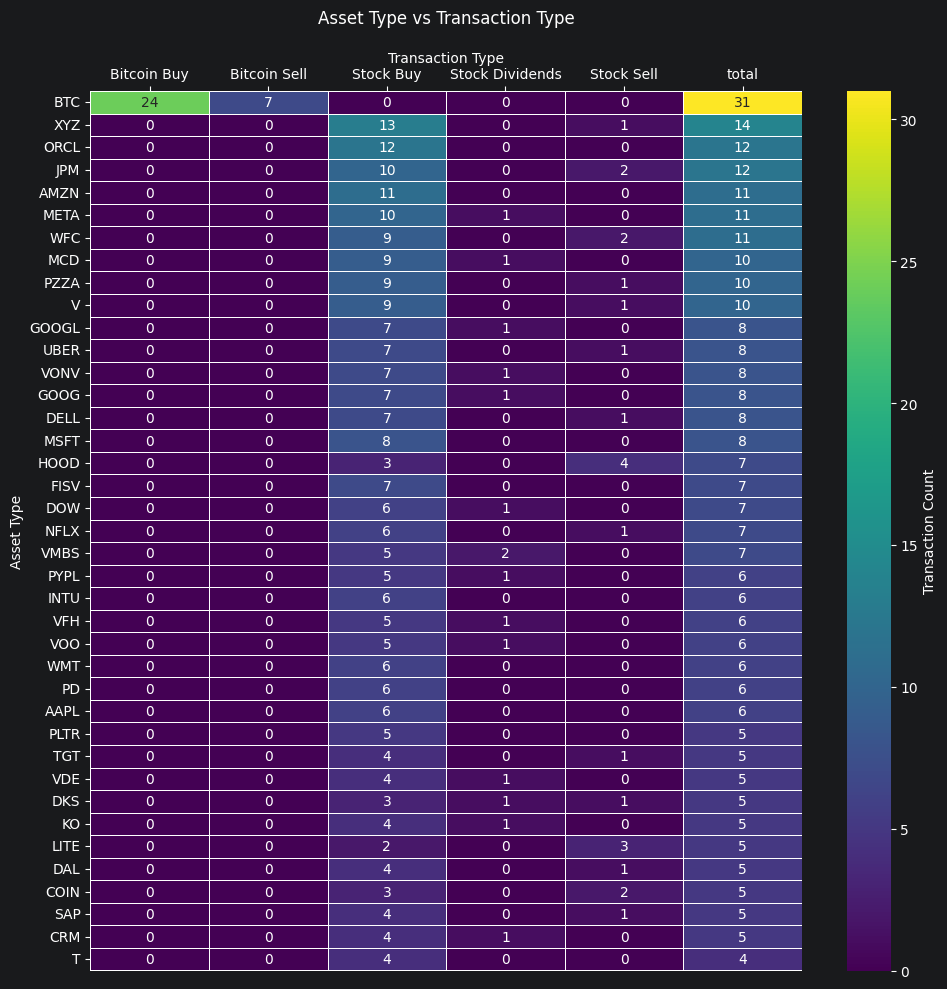

In [20]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [21]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
9,2026-07-06 16:44:23+00:00,9.8,10.0,63170.74,0.000158,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
21,2026-07-02 17:10:19+00:00,19.6,20.0,61217.07,0.000327,-0.4,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN
49,2026-07-01 14:21:49+00:00,-10.0,-9.8,60409.85,0.000162,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00016223,NaN
86,2026-06-26 17:38:10+00:00,-5.0,-4.9,60331.07,0.000081,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00008122,NaN
141,2026-06-20 20:54:15+00:00,9.8,10.0,63371.65,0.000158,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015780,NaN


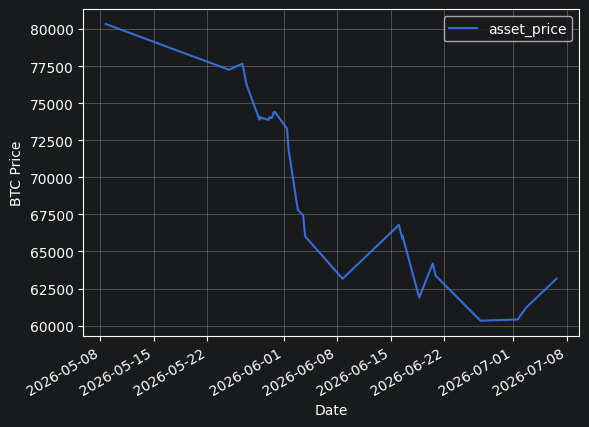

In [22]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [23]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell     7
Name: count, dtype: int64

In [24]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.0
Bitcoin Sell,88.2


In [25]:
data_btc['net_amount'].sum()

np.float64(-163.8)

In [26]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001434
Name: asset_amount, dtype: float64

In [27]:
data_btc['asset_amount'].sum()

np.float64(0.00485381)

In [28]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00198543)

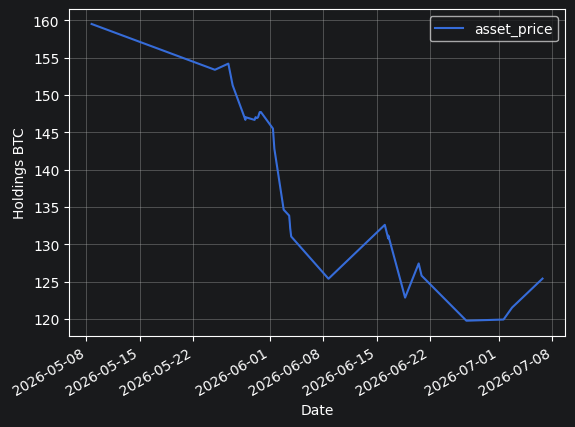

In [29]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [30]:
data_btc['asset_price'] * data_btc['asset_amount']

9       9.999928
21     20.000229
49      9.800290
86      4.900090
141    10.000046
143     4.899747
152    19.999846
234     5.000156
235     4.999899
238     4.900240
274    19.999798
354     9.799846
381     9.800287
405     0.980144
502     9.800221
513     0.979969
530     9.799652
588     4.900136
590     9.799865
593     4.900112
594     9.799903
598     9.799965
602    24.500200
609    24.499951
613    24.500084
632     9.799731
636     9.800031
659    24.499991
676     9.799898
677     4.900356
678     9.799819
dtype: float64

In [31]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
4,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
85,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
114,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
196,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
241,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
289,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
365,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
377,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
390,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
428,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


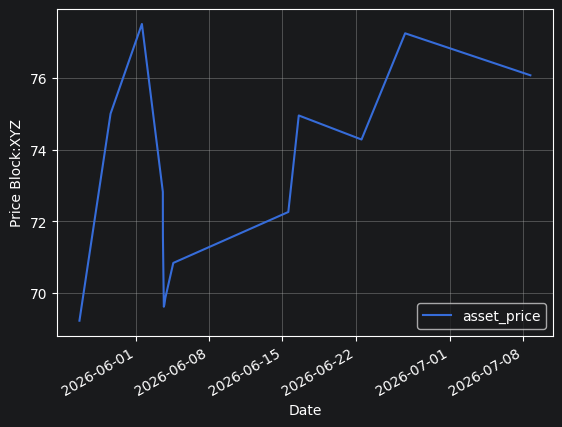

In [32]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [33]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     31
XYZ     14
ORCL    12
JPM     12
AMZN    11
        ..
UNFI     1
UNH      1
EWY      1
ABNB     1
ZG       1
Name: amount, Length: 167, dtype: int64

In [34]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [35]:
data['asset_amount'].describe()

count    686.000000
mean       0.140284
std        0.331200
min        0.000000
25%        0.007935
50%        0.044975
75%        0.127053
max        4.509170
Name: asset_amount, dtype: float64

In [36]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
)
asset_holding_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:30:01+00:00,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,21.666750,0.000000,0.000000,0.000000,0.000000
2026-06-01 13:30:12+00:00,0.000000,0.000000,0.000000,9.9981,0.000000,0.000000,9.549584,0.000000,0.000000,0.000000,...,0.000000,4.945656,0.000000,9.555644,0.0,74.055125,0.000000,0.000000,0.000000,0.000000
2026-06-22 13:30:14+00:00,28.691891,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,21.050186,9.042617,20.071824,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,42.997334,19.954137,9.999727,9.999925
2026-07-06 16:38:52+00:00,51.311805,9.999493,16.180396,9.9981,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,6.862441,55.498870,23.724046,39.646701,0.0,178.314166,52.997013,19.954137,9.999727,9.999925
2026-06-04 13:30:21+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,9.999727,9.999925
2026-07-02 17:06:46+00:00,51.311805,9.999493,16.180396,9.9981,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,6.862441,55.498870,23.724046,39.646701,0.0,178.314166,52.997013,19.954137,9.999727,9.999925
2026-06-01 13:30:28+00:00,0.000000,0.000000,0.000000,9.9981,9.998914,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,4.945656,0.000000,9.555644,0.0,74.055125,0.000000,0.000000,0.000000,0.000000
2026-06-24 13:31:03+00:00,37.937295,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,26.856968,75.498388,23.724046,27.762524,0.0,171.057249,42.997334,19.954137,9.999727,9.999925
2026-06-18 17:15:09+00:00,28.691891,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925


In [37]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3773.6268336)

In [38]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-08 04:00:00+00:00,0.016247,0.00265,0.004288,0.002649,0.0,0.00265,0.0,0.005578,0.002396,0.007968,...,0.001819,0.014707,0.006287,0.013013,0.0,0.047253,0.014044,0.005288,0.00265,0.00265
2026-07-08 17:05:18+00:00,0.016247,0.00265,0.004288,0.002649,0.0,0.00265,0.0,0.005578,0.002396,0.007968,...,0.001819,0.014707,0.006287,0.013013,0.0,0.049903,0.014044,0.005288,0.00265,0.00265
2026-07-09 16:35:19+00:00,0.016247,0.00265,0.004288,0.002649,0.0,0.00265,0.0,0.005578,0.002396,0.007968,...,0.001819,0.014707,0.006287,0.015662,0.0,0.049903,0.014044,0.005288,0.00265,0.00265
2026-07-09 16:35:34+00:00,0.016247,0.00265,0.004288,0.002649,0.0,0.00265,0.0,0.005578,0.002396,0.007968,...,0.001819,0.014707,0.006287,0.015662,0.0,0.049903,0.014044,0.005288,0.00265,0.00265
2026-07-09 16:52:07+00:00,0.016247,0.00265,0.004288,0.002649,0.0,0.00265,0.0,0.005578,0.002396,0.007968,...,0.001819,0.014707,0.006287,0.015662,0.0,0.049903,0.014044,0.005288,0.00265,0.00265


In [39]:
asset_price_rel.iloc[-1].describe()

count    167.000000
mean       0.005988
std        0.007534
min        0.000000
25%        0.001999
50%        0.003941
75%        0.006768
max        0.049903
Name: 2026-07-09 16:52:07+00:00, dtype: float64

In [40]:
asset_price_rel.iloc[-1].sort_values(ascending=False).head()

asset_type
XYZ     0.049903
AMZN    0.043512
DELL    0.027423
MCD     0.025972
UBER    0.025483
Name: 2026-07-09 16:52:07+00:00, dtype: float64

In [41]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-08 04:00:00+00:00,0.016247,0.00265,0.004288,0.002649,0.0,0.00265,0.0,0.005578,0.002396,0.007968,...,0.001819,0.014707,0.006287,0.013013,0.0,0.047253,0.014044,0.005288,0.00265,0.00265
2026-07-08 17:05:18+00:00,0.016247,0.00265,0.004288,0.002649,0.0,0.00265,0.0,0.005578,0.002396,0.007968,...,0.001819,0.014707,0.006287,0.013013,0.0,0.049903,0.014044,0.005288,0.00265,0.00265
2026-07-09 16:35:19+00:00,0.016247,0.00265,0.004288,0.002649,0.0,0.00265,0.0,0.005578,0.002396,0.007968,...,0.001819,0.014707,0.006287,0.015662,0.0,0.049903,0.014044,0.005288,0.00265,0.00265
2026-07-09 16:35:34+00:00,0.016247,0.00265,0.004288,0.002649,0.0,0.00265,0.0,0.005578,0.002396,0.007968,...,0.001819,0.014707,0.006287,0.015662,0.0,0.049903,0.014044,0.005288,0.00265,0.00265
2026-07-09 16:52:07+00:00,0.016247,0.00265,0.004288,0.002649,0.0,0.00265,0.0,0.005578,0.002396,0.007968,...,0.001819,0.014707,0.006287,0.015662,0.0,0.049903,0.014044,0.005288,0.00265,0.00265


In [42]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-02 17:07:58+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:28+00:00,NaN,NaN,NaN,NaN,223.99,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-18 17:17:31+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-02 16:52:54+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-04 13:30:11+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-02 17:06:46+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 13:30:40+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 17:35:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-20 20:54:15+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-02 17:07:58+00:00,0.950374,1.0,0.719207,1.0,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.075766,0.995338,1.0,1.0
2026-06-01 13:30:28+00:00,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.083345,1.000000,1.000000,1.0,1.0
2026-06-18 17:17:31+00:00,1.018386,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,0.995338,1.0,1.0
2026-06-02 16:52:54+00:00,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.000000,1.0,1.0
2026-06-04 13:30:11+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.016406,0.968648,0.976969,1.0,1.009245,0.997325,1.000000,1.0,1.0
2026-07-02 17:06:46+00:00,0.950374,1.0,0.719207,1.0,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.075766,0.995338,1.0,1.0
2026-06-22 13:30:40+00:00,0.969248,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,1.005550,0.995338,1.0,1.0
2026-06-03 17:35:10+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.976969,1.0,1.006356,1.000000,1.000000,1.0,1.0
2026-06-20 20:54:15+00:00,1.018386,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,0.995338,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

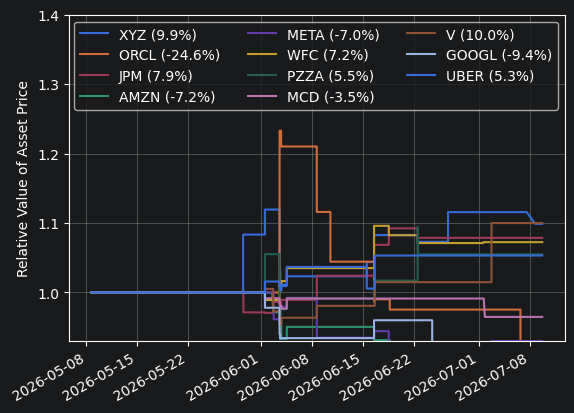

In [44]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [45]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-07 13:30:16+00:00    1.115701
2026-07-07 13:31:54+00:00    1.115701
2026-07-08 17:05:18+00:00    1.098801
2026-07-09 16:35:19+00:00    1.098801
2026-07-09 16:35:34+00:00    1.098801
Name: XYZ, Length: 433, dtype: float64

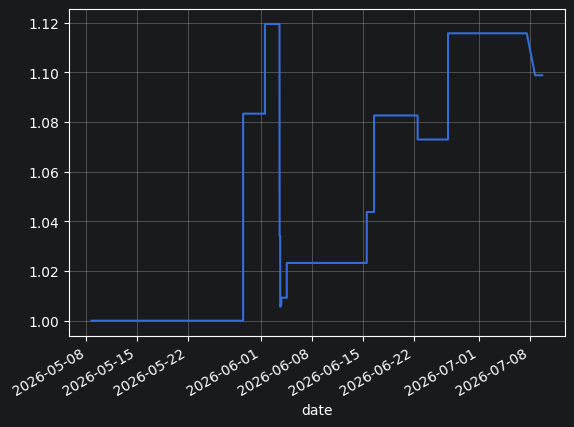

In [46]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [47]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
    .sort_values('date', ascending=False)
)
div_data

,date,amount,asset_type,notes
1,2026-07-09,0.02,TSM,$0.02 Dividend from Taiwan Semiconductor Manuf...
5,2026-07-08,0.07,MRK,$0.07 Dividend from Merck
15,2026-07-06,0.04,BIV,$0.04 Dividend from Vanguard Intermediate Term...
16,2026-07-06,0.07,JEPI,$0.07 Dividend from JPMorgan Equity Premium In...
17,2026-07-06,0.05,BNDX,$0.05 Dividend from Vanguard Total Internation...
18,2026-07-06,0.04,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
19,2026-07-06,0.06,VGLT,$0.06 Dividend from Vanguard Long-Treasury ETF
20,2026-07-06,0.11,VMBS,$0.11 Dividend from Vanguard Mortgage-Backed S...
39,2026-07-02,0.05,CRM,$0.05 Dividend from Salesforce
78,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing


In [48]:
div_data['amount'].sum()

np.float64(4.03)

In [49]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
90,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
75,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
97,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
93,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
236,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
87,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
76,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
88,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
107,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...
78,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing


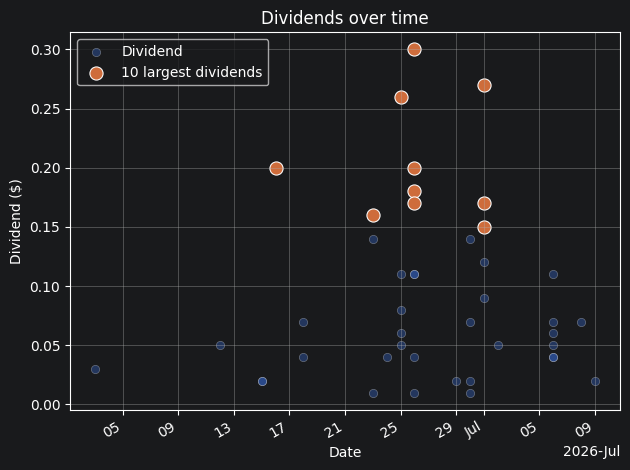

In [50]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [51]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
60,2026-07-01 14:17:44+00:00,-10.00,686.18,$10 Purchase of Vanguard S&P 500 ETF,VOO
418,2026-06-03 15:06:50+00:00,-10.00,159.33,$10 Purchase of Vanguard FTSE All World ex US ...,VSS
569,2026-06-01 13:30:11+00:00,-10.00,125.85,$10 Purchase of Vanguard Financials ETF,VFH
497,2026-06-03 13:30:00+00:00,-10.00,76.30,$10 Purchase of Vanguard Intermediate Term Bon...,BIV
460,2026-06-03 13:30:11+00:00,-10.00,390.01,$10 Purchase of Vanguard Consumer Discretionar...,VCR
328,2026-06-03 19:46:16+00:00,-10.00,275.16,$10 Purchase of Vanguard Health Care ETF,VHT
87,2026-06-26 04:00:00+00:00,0.18,NaN,$0.18 Dividend from Vanguard Real Estate ETF,VNQ
243,2026-06-15 13:30:28+00:00,-10.00,127.25,$10 Purchase of Vanguard Russell 1000 Growth ETF,VONG
129,2026-06-22 13:30:14+00:00,-10.00,131.87,$10 Purchase of Vanguard Financials ETF,VFH
38,2026-07-02 13:30:00+00:00,-10.00,76.38,$10 Purchase of Vanguard Intermediate Term Bon...,BIV


In [52]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    8
VMBS    7
VOO     6
VFH     6
VDE     5
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VGLT    3
VBR     3
VCR     3
VDC     3
VONG    3
BSV     1
Name: count, dtype: int64

In [53]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
60,2026-07-01 14:17:44+00:00,-10.00,686.18,VOO,Vanguard S&P 500 ETF
418,2026-06-03 15:06:50+00:00,-10.00,159.33,VSS,Vanguard FTSE All World ex US Small Cap ETF
569,2026-06-01 13:30:11+00:00,-10.00,125.85,VFH,Vanguard Financials ETF
497,2026-06-03 13:30:00+00:00,-10.00,76.30,BIV,Vanguard Intermediate Term Bond ETF
460,2026-06-03 13:30:11+00:00,-10.00,390.01,VCR,Vanguard Consumer Discretionary ETF
328,2026-06-03 19:46:16+00:00,-10.00,275.16,VHT,Vanguard Health Care ETF
87,2026-06-26 04:00:00+00:00,0.18,NaN,VNQ,NaN
243,2026-06-15 13:30:28+00:00,-10.00,127.25,VONG,Vanguard Russell 1000 Growth ETF
129,2026-06-22 13:30:14+00:00,-10.00,131.87,VFH,Vanguard Financials ETF
38,2026-07-02 13:30:00+00:00,-10.00,76.38,BIV,Vanguard Intermediate Term Bond ETF


In [54]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                7
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VOO         Vanguard S&P 500 ETF                           5
VFH         Vanguard Financials ETF                        5
VDE         Energy ETF Vanguard                            4
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VHT         Vanguard Health Care ETF                       3
BIV         Vanguard Intermediate Term Bond ETF            2
VONG        Vanguard Russell 1000 Growth ETF               2
VNQ         Vanguard Real Estate ETF                       2
VGLT        Vanguard Long-Treasury ETF                     2
BNDX        Vanguard Total International Bond ETF          2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VCR         Vanguard Consumer Discretionary ETF            2
VBR         Small Cap Value ETF Vanguard                   2
VTEB        Vanguard Tax-Exem

In [55]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VMBS,VOO,VFH,VDE,VNQ,VHT,VSS,BIV,BNDX,VTEB,VGLT,VBR,VCR,VDC,VONG,BSV
date,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
vanguard_trans_count

asset_type
VONV    8
VMBS    7
VOO     6
VFH     6
VDE     5
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VGLT    3
VBR     3
VCR     3
VDC     3
VONG    3
BSV     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

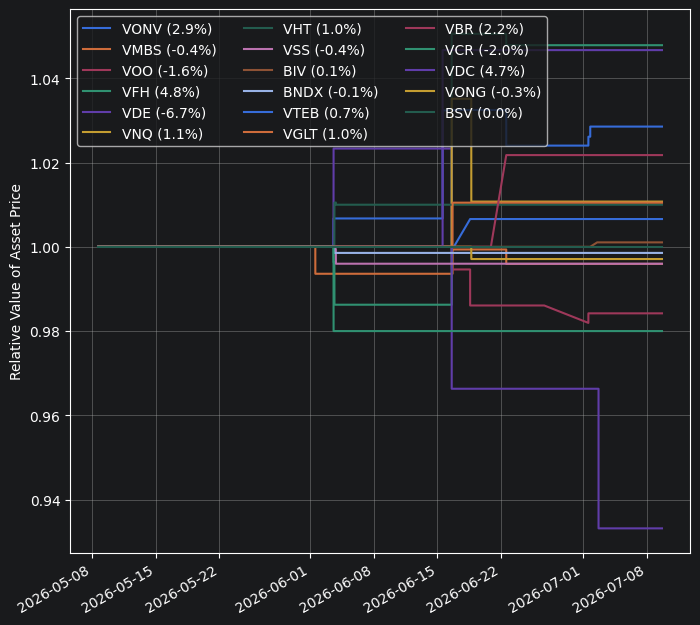

In [57]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [58]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
40,2026-07-01 20:14:16+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
65,2026-07-01 13:41:36+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
140,2026-06-21 21:31:19+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
142,2026-06-20 12:23:07+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
153,2026-06-18 17:13:20+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
670,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
671,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
672,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
673,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [59]:
data_deposits['net_amount'].sum()

np.float64(5735.96)

In [60]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,65.0,88.245538,49.961254,1.0,50.0,100.0,100.0,200.0


In [61]:
data_deposits['net_amount'].cumsum()

40      100.00
65      200.00
140     300.00
142     400.00
153     500.00
        ...   
670    5630.96
671    5640.96
672    5690.96
673    5710.96
674    5735.96
Name: net_amount, Length: 65, dtype: float64

In [62]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
674,2026-05-26 19:39:34+00:00,25.00
673,2026-05-26 21:58:29+00:00,45.00
672,2026-05-27 00:43:01+00:00,95.00
671,2026-05-27 00:56:05+00:00,105.00
670,2026-05-27 00:56:27+00:00,205.00
...,...,...
153,2026-06-18 17:13:20+00:00,5335.96
142,2026-06-20 12:23:07+00:00,5435.96
140,2026-06-21 21:31:19+00:00,5535.96
65,2026-07-01 13:41:36+00:00,5635.96


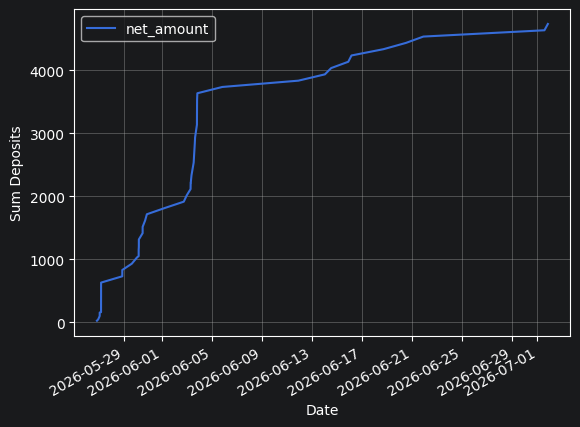

In [63]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [64]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [65]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4400.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64